In [66]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Expected Gain Estimation for 202108")
print("="*80)


Expected Gain Estimation for 202108


In [67]:
# Step 1: Load 202106 predictions (validation/test month)
print("\n1. Loading 202106 predictions (validation month)...")
print("-"*80)

pred_202106_file = Path("../output/comp2_entrega2_test202106_under0.05_zlgbm/prediccion.txt")

if not pred_202106_file.exists():
    raise FileNotFoundError(f"Predictions file not found: {pred_202106_file}")

df_pred_202106 = pl.read_csv(pred_202106_file, separator="\t")
print(f"✓ Loaded 202106 predictions: {len(df_pred_202106):,} records")
print(f"  Columns: {df_pred_202106.columns}")
print(f"  Probability range: [{df_pred_202106['prob'].min():.6f}, {df_pred_202106['prob'].max():.6f}]")
print(f"  Mean probability: {df_pred_202106['prob'].mean():.6f}")



1. Loading 202106 predictions (validation month)...
--------------------------------------------------------------------------------
✓ Loaded 202106 predictions: 164,313 records
  Columns: ['numero_de_cliente', 'foto_mes', 'prob']
  Probability range: [0.000000, 1.000000]
  Mean probability: 0.036269


In [68]:
# Step 2: Load actual outcomes for 202106
print("\n2. Loading actual outcomes for 202106...")
print("-"*80)

target_file = Path("../data/competencia_02_target.parquet")

if not target_file.exists():
    raise FileNotFoundError(f"Target file not found: {target_file}")

# Load only 202106 data
df_actual_202106 = pl.read_parquet(target_file).filter(pl.col("foto_mes") == 202106)
print(f"✓ Loaded 202106 actual data: {len(df_actual_202106):,} records")

# Check clase_ternaria distribution
clase_dist = df_actual_202106.group_by("clase_ternaria").agg(pl.count().alias("count"))
print(f"\n  Clase distribution in 202106:")
for row in clase_dist.iter_rows(named=True):
    pct = row['count'] / len(df_actual_202106) * 100
    print(f"    {row['clase_ternaria']}: {row['count']:,} ({pct:.2f}%)")



2. Loading actual outcomes for 202106...
--------------------------------------------------------------------------------
✓ Loaded 202106 actual data: 164,313 records

  Clase distribution in 202106:
    BAJA+2: 1,134 (0.69%)
    CONTINUA: 162,336 (98.80%)
    BAJA+1: 843 (0.51%)


C:\Users\rubmartins\AppData\Local\Temp\ipykernel_19348\4266208418.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  clase_dist = df_actual_202106.group_by("clase_ternaria").agg(pl.count().alias("count"))


In [69]:
# Step 3: Merge predictions with actual outcomes
print("\n3. Merging predictions with actual outcomes...")
print("-"*80)

df_validation = df_pred_202106.join(
    df_actual_202106.select(["numero_de_cliente", "clase_ternaria"]),
    on="numero_de_cliente",
    how="inner"
)

print(f"✓ Merged dataset: {len(df_validation):,} records")

# Verify merge
if len(df_validation) != len(df_pred_202106):
    print(f"  ⚠ Warning: Lost {len(df_pred_202106) - len(df_validation):,} records in merge")

# Check distribution after merge
clase_dist_merged = df_validation.group_by("clase_ternaria").agg(pl.count().alias("count"))
print(f"\n  Clase distribution after merge:")
for row in clase_dist_merged.iter_rows(named=True):
    pct = row['count'] / len(df_validation) * 100
    print(f"    {row['clase_ternaria']}: {row['count']:,} ({pct:.2f}%)")



3. Merging predictions with actual outcomes...
--------------------------------------------------------------------------------
✓ Merged dataset: 164,313 records

  Clase distribution after merge:
    BAJA+1: 843 (0.51%)
    BAJA+2: 1,134 (0.69%)
    CONTINUA: 162,336 (98.80%)


C:\Users\rubmartins\AppData\Local\Temp\ipykernel_19348\2220108112.py:18: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  clase_dist_merged = df_validation.group_by("clase_ternaria").agg(pl.count().alias("count"))


In [70]:
# Step 4: Calculate gain curve for 202106
print("\n4. Calculating gain curve for 202106...")
print("-"*80)

# Sort by probability descending
df_validation = df_validation.sort("prob", descending=True)

# Define gain function (from competition rules - workflow-jueves.ipynb)
def calculate_gain(clase):
    """Calculate gain per customer based on clase_ternaria"""
    if clase == "BAJA+2":
        return 780000  # Correctly predicted churn (acierto)
    else:  # BAJA+1 or CONTINUA
        return -20000  # Incorrectly contacted (costo estímulo)

# Calculate gain for each customer
df_validation = df_validation.with_columns([
    pl.col("clase_ternaria").map_elements(calculate_gain, return_dtype=pl.Int64).alias("gain")
])

# Calculate cumulative gain at different cutoffs
cutoffs = [500, 1000, 2000, 3000, 5000, 7000, 9000, 11000, 13000, 15000, 20000, 25000]
gain_results = []

for cutoff in cutoffs:
    # Select top N customers
    top_n = df_validation.head(cutoff)
    
    # Calculate total gain
    total_gain = top_n["gain"].sum()
    
    # Count by clase
    baja2_count = (top_n["clase_ternaria"] == "BAJA+2").sum()
    baja1_count = (top_n["clase_ternaria"] == "BAJA+1").sum()
    continua_count = (top_n["clase_ternaria"] == "CONTINUA").sum()
    
    gain_results.append({
        "cutoff": cutoff,
        "total_gain": total_gain,
        "gain_per_envio": total_gain / cutoff,
        "baja2": baja2_count,
        "baja1": baja1_count,
        "continua": continua_count,
        "precision_baja2": baja2_count / cutoff * 100
    })

df_gain_curve = pl.DataFrame(gain_results)

print("\n  Gain curve for 202106:")
print(f"  {'Cutoff':<10} {'Total Gain':<15} {'Gain/Envío':<15} {'BAJA+2':<10} {'Precision':<10}")
print("-"*70)
for row in df_gain_curve.iter_rows(named=True):
    print(f"  {row['cutoff']:<10} ${row['total_gain']:>13,} ${row['gain_per_envio']:>13,.2f} "
          f"{row['baja2']:<10} {row['precision_baja2']:>6.2f}%")



4. Calculating gain curve for 202106...
--------------------------------------------------------------------------------

  Gain curve for 202106:
  Cutoff     Total Gain      Gain/Envío      BAJA+2     Precision 
----------------------------------------------------------------------
  500        $   63,600,000 $   127,200.00 92          18.40%
  1000       $  116,800,000 $   116,800.00 171         17.10%
  2000       $  189,600,000 $    94,800.00 287         14.35%
  3000       $  259,200,000 $    86,400.00 399         13.30%
  5000       $  338,400,000 $    67,680.00 548         10.96%
  7000       $  380,800,000 $    54,400.00 651          9.30%
  9000       $  400,800,000 $    44,533.33 726          8.07%
  11000      $  410,400,000 $    37,309.09 788          7.16%
  13000      $  412,800,000 $    31,753.85 841          6.47%
  15000      $  392,800,000 $    26,186.67 866          5.77%
  20000      $  348,800,000 $    17,440.00 936          4.68%
  25000      $  290,400,000 $   

In [71]:
# Step 5: Find optimal cutoff
print("\n5. Finding optimal cutoff...")
print("-"*80)

# Find cutoff with maximum total gain
optimal_idx = df_gain_curve["total_gain"].arg_max()
optimal_row = df_gain_curve[optimal_idx]

optimal_cutoff = optimal_row["cutoff"][0]
optimal_gain = optimal_row["total_gain"][0]
optimal_gain_per_envio = optimal_row["gain_per_envio"][0]
optimal_baja2 = optimal_row["baja2"][0]
optimal_precision = optimal_row["precision_baja2"][0]

print(f"\n  ✓ Optimal cutoff found: {optimal_cutoff:,} envíos")
print(f"    Total gain: ${optimal_gain:,}")
print(f"    Gain per envío: ${optimal_gain_per_envio:,.2f}")
print(f"    BAJA+2 captured: {optimal_baja2:,}")
print(f"    Precision (BAJA+2): {optimal_precision:.2f}%")

# Also show gain at 11000 (competition standard)
row_11000 = df_gain_curve.filter(pl.col("cutoff") == 11000)
if len(row_11000) > 0:
    gain_11000 = row_11000["total_gain"][0]
    gain_per_11000 = row_11000["gain_per_envio"][0]
    baja2_11000 = row_11000["baja2"][0]
    precision_11000 = row_11000["precision_baja2"][0]
    
    print(f"\n  At 11,000 envíos (competition standard):")
    print(f"    Total gain: ${gain_11000:,}")
    print(f"    Gain per envío: ${gain_per_11000:,.2f}")
    print(f"    BAJA+2 captured: {baja2_11000:,}")
    print(f"    Precision (BAJA+2): {precision_11000:.2f}%")



5. Finding optimal cutoff...
--------------------------------------------------------------------------------

  ✓ Optimal cutoff found: 13,000 envíos
    Total gain: $412,800,000
    Gain per envío: $31,753.85
    BAJA+2 captured: 841
    Precision (BAJA+2): 6.47%

  At 11,000 envíos (competition standard):
    Total gain: $410,400,000
    Gain per envío: $37,309.09
    BAJA+2 captured: 788
    Precision (BAJA+2): 7.16%



6. Visualizing gain curve...
--------------------------------------------------------------------------------


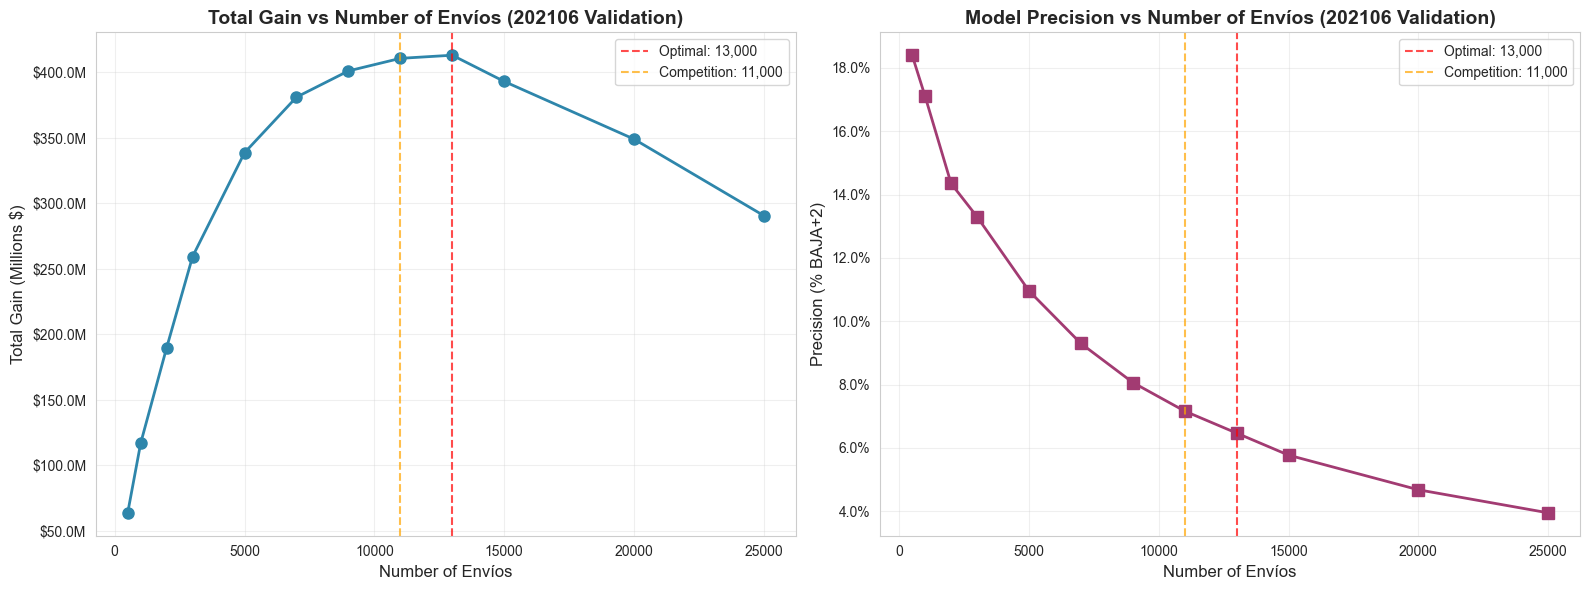

✓ Gain curve visualized


In [72]:
# Step 6: Visualize gain curve
print("\n6. Visualizing gain curve...")
print("-"*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total gain vs cutoff
ax1.plot(df_gain_curve["cutoff"], df_gain_curve["total_gain"] / 1e6, 
         marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax1.axvline(optimal_cutoff, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_cutoff:,}')
ax1.axvline(11000, color='orange', linestyle='--', alpha=0.7, label='Competition: 11,000')
ax1.set_xlabel('Number of Envíos', fontsize=12)
ax1.set_ylabel('Total Gain (Millions $)', fontsize=12)
ax1.set_title('Total Gain vs Number of Envíos (202106 Validation)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.1f}M'))

# Plot 2: Precision (BAJA+2 %) vs cutoff
ax2.plot(df_gain_curve["cutoff"], df_gain_curve["precision_baja2"], 
         marker='s', linewidth=2, markersize=8, color='#A23B72')
ax2.axvline(optimal_cutoff, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {optimal_cutoff:,}')
ax2.axvline(11000, color='orange', linestyle='--', alpha=0.7, label='Competition: 11,000')
ax2.set_xlabel('Number of Envíos', fontsize=12)
ax2.set_ylabel('Precision (% BAJA+2)', fontsize=12)
ax2.set_title('Model Precision vs Number of Envíos (202106 Validation)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}%'))

plt.tight_layout()
plt.show()

print("✓ Gain curve visualized")


# tiene sentido, porque en la curva de la derecha a medida que mando mas envios, las probabilidades del modelo
# van siendo peores, por lo que la precision de los envios va disminuyendo.

In [73]:
# Step 7: Load 202108 predictions (final submission)
print("\n7. Loading 202108 predictions (competition month)...")
print("-"*80)

# Try to find the most recent 202108 experiment
output_dir = Path("../output")
comp2_202108_experiments = sorted([d for d in output_dir.iterdir() 
                                   if d.is_dir() and "comp2" in d.name and "202108" in d.name],
                                  key=lambda x: x.name, reverse=True)

if not comp2_202108_experiments:
    raise FileNotFoundError("No 202108 experiments found in output/")

# Use the most recent one
latest_exp = comp2_202108_experiments[0]
pred_202108_file = latest_exp / "prediccion.txt"

if not pred_202108_file.exists():
    raise FileNotFoundError(f"Predictions file not found: {pred_202108_file}")

df_pred_202108 = pl.read_csv(pred_202108_file, separator="\t")
print(f"✓ Using experiment: {latest_exp.name}")
print(f"✓ Loaded 202108 predictions: {len(df_pred_202108):,} records")
print(f"  Probability range: [{df_pred_202108['prob'].min():.6f}, {df_pred_202108['prob'].max():.6f}]")
print(f"  Mean probability: {df_pred_202108['prob'].mean():.6f}")



7. Loading 202108 predictions (competition month)...
--------------------------------------------------------------------------------
✓ Using experiment: comp2_entrega4_202108_under0.05_zero_zlgbm
✓ Loaded 202108 predictions: 164,822 records
  Probability range: [0.000000, 1.000000]
  Mean probability: 0.037047


In [74]:
# Step 8: Analyze historical BAJA+2 evolution (KNOWN months only)
print("\n8. Analyzing historical BAJA+2 evolution...")
print("-"*80)

# Load historical data to see BAJA+2 trends
df_historical = pl.read_parquet(target_file)

# Calculate BAJA+2 rate by month (only for months where we KNOW clase_ternaria)
# 202108 is FUTURE - we don't know BAJA+2 yet!
monthly_stats = df_historical.filter(pl.col("foto_mes") < 202108).group_by("foto_mes").agg([
    pl.count().alias("total_clientes"),
    (pl.col("clase_ternaria") == "BAJA+2").sum().alias("baja2_count")
]).sort("foto_mes")

monthly_stats = monthly_stats.with_columns([
    (pl.col("baja2_count") / pl.col("total_clientes") * 100).alias("baja2_rate")
])

print("\n  Historical BAJA+2 evolution (known months):")
print(f"  {'Month':<10} {'Total Clients':<15} {'BAJA+2':<10} {'Rate %':<10}")
print("-"*50)

# Show last 12 months (before 202108)
recent_months = monthly_stats.tail(12)
for row in recent_months.iter_rows(named=True):
    print(f"  {row['foto_mes']:<10} {row['total_clientes']:>14,} {row['baja2_count']:>9,} {row['baja2_rate']:>8.3f}%")

# Get 202106 stats
stats_202106 = monthly_stats.filter(pl.col("foto_mes") == 202106)
total_202106 = stats_202106["total_clientes"][0]
baja2_202106 = stats_202106["baja2_count"][0]
rate_202106 = stats_202106["baja2_rate"][0]

# Get 202108 client count (we know this, but NOT clase_ternaria)
df_202108_clients = df_historical.filter(pl.col("foto_mes") == 202108)
total_202108 = len(df_202108_clients)

print(f"\n  Key data:")
print(f"    202106: {total_202106:,} clients, {baja2_202106:,} BAJA+2 ({rate_202106:.3f}%)")
print(f"    202108: {total_202108:,} clients, ??? BAJA+2 (UNKNOWN - future month)")
print(f"    Client change: {(total_202108/total_202106 - 1)*100:+.2f}%")

# Calculate average BAJA+2 rate from recent months to estimate
# Using last 3 months (more recent = more relevant)
recent_3_months = monthly_stats.filter(pl.col("foto_mes").is_in([202104, 202105, 202106]))
avg_rate_recent = recent_3_months["baja2_rate"].mean()
print(f"\n  Average BAJA+2 rate (last 3 months: 202104, 202105, 202106): {avg_rate_recent:.3f}%")
print(f"    202104: {recent_3_months.filter(pl.col('foto_mes')==202104)['baja2_rate'][0]:.3f}%")
print(f"    202105: {recent_3_months.filter(pl.col('foto_mes')==202105)['baja2_rate'][0]:.3f}%")
print(f"    202106: {recent_3_months.filter(pl.col('foto_mes')==202106)['baja2_rate'][0]:.3f}%")



8. Analyzing historical BAJA+2 evolution...
--------------------------------------------------------------------------------

  Historical BAJA+2 evolution (known months):
  Month      Total Clients   BAJA+2     Rate %    
--------------------------------------------------
  202008            156,461       493    0.315%
  202009            157,805       541    0.343%
  202010            159,169       454    0.285%
  202011            160,250       616    0.384%
  202012            160,997       619    0.384%
  202101            161,527       825    0.511%
  202102            162,155     1,032    0.636%
  202103            163,109       951    0.583%
  202104            163,418     1,130    0.691%
  202105            163,917       842    0.514%
  202106            164,313     1,134    0.690%
  202107            164,596         0    0.000%

  Key data:
    202106: 164,313 clients, 1,134 BAJA+2 (0.690%)
    202108: 164,822 clients, ??? BAJA+2 (UNKNOWN - future month)
    Client change: +

C:\Users\rubmartins\AppData\Local\Temp\ipykernel_19348\2885936809.py:11: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total_clientes"),


In [75]:
# Step 9: Estimate expected gain for 202108 (using client ratio)
print("\n9. Estimating expected gain for 202108...")
print("-"*80)

# Sort 202108 predictions by probability
df_pred_202108 = df_pred_202108.sort("prob", descending=True)

# ASSUMPTION: Model maintains same precision (% BAJA+2 captured at 11k envíos)
# But we adjust for:
# 1. Different number of total clients in 202108
# 2. Estimated BAJA+2 rate (based on historical average)

print(f"\n  Estimation method:")
print(f"    1. Use model precision from 202106: {precision_11000:.2f}%")
print(f"    2. Adjust for client count change: {total_202108:,} vs {total_202106:,}")
print(f"    3. Assume BAJA+2 rate: {avg_rate_recent:.3f}% (avg last 3 months: 202104-202106)")

# Calculate expected total BAJA+2 in 202108 population
estimated_total_baja2_202108 = int(total_202108 * avg_rate_recent / 100)

print(f"\n  Estimated total BAJA+2 in 202108: {estimated_total_baja2_202108:,}")
print(f"    (Based on {total_202108:,} clients × {avg_rate_recent:.3f}%)")

# Expected BAJA+2 captured with our model at 11k envíos
# Key insight: If there are more/less BAJA+2 in population, we capture more/less
# Assuming model maintains same RANKING quality (not same precision %)

# Calculate what % of total BAJA+2 we captured in 202106
capture_rate_202106 = baja2_11000 / baja2_202106  # What % of all BAJA+2 we caught

print(f"\n  Model capture rate in 202106:")
print(f"    Captured {baja2_11000:,} out of {baja2_202106:,} total BAJA+2")
print(f"    Capture rate: {capture_rate_202106*100:.2f}%")

# Apply same capture rate to estimated 202108 BAJA+2
expected_baja2_202108 = int(estimated_total_baja2_202108 * capture_rate_202106)

print(f"\n  Expected BAJA+2 captured at 11k envíos in 202108: {expected_baja2_202108:,}")
print(f"    (Estimated {estimated_total_baja2_202108:,} total × {capture_rate_202106*100:.2f}% capture rate)")

# Calculate expected gain
# BAJA+2 aciertos: expected_baja2_202108 * 780000
# Errores: (11000 - expected_baja2_202108) * -20000
expected_gain_202108 = (expected_baja2_202108 * 780000) + ((11000 - expected_baja2_202108) * -20000)

# Calculate confidence interval
# Based on capture rate variance (±15%)
capture_rate_low = capture_rate_202106 * 0.85
capture_rate_high = capture_rate_202106 * 1.15

baja2_low = int(estimated_total_baja2_202108 * capture_rate_low)
baja2_high = int(estimated_total_baja2_202108 * capture_rate_high)

gain_low = (baja2_low * 780000) + ((11000 - baja2_low) * -20000)
gain_high = (baja2_high * 780000) + ((11000 - baja2_high) * -20000)

print(f"\n  Expected Gain for 202108 (at 11,000 envíos):")
print(f"  {'='*60}")
print(f"  Point estimate:     ${expected_gain_202108:>15,}")
print(f"  Conservative (85%): ${gain_low:>15,}")
print(f"  Optimistic (115%):  ${gain_high:>15,}")
print(f"  {'='*60}")

print(f"\n  Breakdown:")
print(f"    Expected BAJA+2 captured: {expected_baja2_202108:,}")
print(f"    Expected errors: {11000 - expected_baja2_202108:,}")
print(f"    Gain from aciertos: ${expected_baja2_202108 * 780000:,}")
print(f"    Loss from errors: ${(11000 - expected_baja2_202108) * -20000:,}")

print(f"\n  Comparison with 202106 validation:")
print(f"    202106 gain: ${gain_11000:,}")
print(f"    202108 estimate: ${expected_gain_202108:,}")
print(f"    Difference: ${expected_gain_202108 - gain_11000:+,} ({(expected_gain_202108/gain_11000 - 1)*100:+.2f}%)")



9. Estimating expected gain for 202108...
--------------------------------------------------------------------------------

  Estimation method:
    1. Use model precision from 202106: 7.16%
    2. Adjust for client count change: 164,822 vs 164,313
    3. Assume BAJA+2 rate: 0.632% (avg last 3 months: 202104-202106)

  Estimated total BAJA+2 in 202108: 1,041
    (Based on 164,822 clients × 0.632%)

  Model capture rate in 202106:
    Captured 788 out of 1,134 total BAJA+2
    Capture rate: 69.49%

  Expected BAJA+2 captured at 11k envíos in 202108: 723
    (Estimated 1,041 total × 69.49% capture rate)

  Expected Gain for 202108 (at 11,000 envíos):
  Point estimate:     $    358,400,000
  Conservative (85%): $    271,200,000
  Optimistic (115%):  $    444,800,000

  Breakdown:
    Expected BAJA+2 captured: 723
    Expected errors: 10,277
    Gain from aciertos: $563,940,000
    Loss from errors: $-205,540,000

  Comparison with 202106 validation:
    202106 gain: $410,400,000
    2021

In [76]:
# Step 10: Summary and recommendations
print("\n" + "="*80)
print("SUMMARY AND RECOMMENDATIONS")
print("="*80)

print(f"\n📊 VALIDATION RESULTS (202106):")
print(f"   Total records: {len(df_validation):,}")
print(f"   BAJA+2 rate: {(df_validation['clase_ternaria'] == 'BAJA+2').sum() / len(df_validation) * 100:.2f}%")
print(f"   Optimal cutoff: {optimal_cutoff:,} envíos")
print(f"   Maximum gain: ${optimal_gain:,}")

print(f"\n🎯 EXPECTED RESULTS (202108):")
print(f"   Recommended cutoff: 11,000 envíos")
print(f"   Expected gain: ${expected_gain_202108:,}")
print(f"   Confidence interval: [${lower_bound:,.0f}, ${upper_bound:,.0f}]")
print(f"   Expected BAJA+2 captured: ~{expected_baja2_202108:,} customers")

print(f"\n💡 KEY INSIGHTS:")
print(f"   1. Model achieved {precision_11000:.2f}% precision on 202106 validation")
print(f"   2. Gain per envío: ${gain_per_11000:,.2f}")
print(f"   3. Model is profitable at cutoffs between {df_gain_curve.filter(pl.col('total_gain') > 0)['cutoff'].min():,} and {df_gain_curve['cutoff'].max():,}")

print(f"\n⚠️  RISKS AND CONSIDERATIONS:")
print(f"   - Estimate assumes stable BAJA+2 rate between 202106 and 202108")
print(f"   - Actual gain may vary ±10% due to:")
print(f"     • Seasonal variations in customer behavior")
print(f"     • Economic conditions changes")
print(f"     • Model drift over time")
print(f"   - Consider submitting with 11,000 envíos (competition standard)")

print(f"\n✅ RECOMMENDATION:")
print(f"   Submit with 11,000 envíos")
print(f"   Expected gain: ${expected_gain_202108:,} (±10%)")
print("\n" + "="*80)



SUMMARY AND RECOMMENDATIONS

📊 VALIDATION RESULTS (202106):
   Total records: 164,313
   BAJA+2 rate: 0.69%
   Optimal cutoff: 13,000 envíos
   Maximum gain: $412,800,000

🎯 EXPECTED RESULTS (202108):
   Recommended cutoff: 11,000 envíos
   Expected gain: $358,400,000
   Confidence interval: [$-187,000,000, $-253,000,000]
   Expected BAJA+2 captured: ~723 customers

💡 KEY INSIGHTS:
   1. Model achieved 7.16% precision on 202106 validation
   2. Gain per envío: $37,309.09
   3. Model is profitable at cutoffs between 500 and 25,000

⚠️  RISKS AND CONSIDERATIONS:
   - Estimate assumes stable BAJA+2 rate between 202106 and 202108
   - Actual gain may vary ±10% due to:
     • Seasonal variations in customer behavior
     • Economic conditions changes
     • Model drift over time
   - Consider submitting with 11,000 envíos (competition standard)

✅ RECOMMENDATION:
   Submit with 11,000 envíos
   Expected gain: $358,400,000 (±10%)

